In [1]:
%load_ext autoreload
%autoreload 2

# AlphaZero — Chess Training

This notebook trains an AlphaZero agent on Chess and lets you play against it.

**Notes on training time:**
- Chess games are much longer than Tic-tac-toe (~40–80 moves vs ~5–9)
- Each move requires `num_searches` MCTS simulations
- Start with small hyperparameters for a quick sanity check, then scale up
- MPS (Apple Silicon GPU) is **not** recommended here due to per-call transfer overhead;
  CPU is faster for single-sample MCTS inference

## 1. Imports

In [2]:
import chess
import chess.svg
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython.display import SVG, display, clear_output

from chess_game.chess_game import ChessGame
from model.model import ResNet
from mcts.mcts import MCTS
from train.train import self_play, train_step

## 2. Hyperparameters

Two presets are provided. Start with **Sanity check** to verify everything runs,
then switch to **Full training** for a real experiment.

In [3]:
# --- Sanity check (fast, ~minutes) ---
args = {
    "num_res_blocks":      4,
    "num_hidden":        128,
    "num_searches":       50,   # MCTS simulations per move
    "num_self_play_games": 5,
    "max_moves":          80,   # cap game length during training
    "num_iterations":      5,
    "num_epochs":          4,
    "batch_size":         64,
    "lr":               1e-3,
}

# --- Full training (slow, ~hours on M1) ---
# args = {
#     "num_res_blocks":      8,
#     "num_hidden":        256,
#     "num_searches":      200,
#     "num_self_play_games": 25,
#     "max_moves":         200,
#     "num_iterations":     50,
#     "num_epochs":          5,
#     "batch_size":        256,
#     "lr":              1e-3,
# }

## 3. Initialise

In [4]:
# Use CPU — MPS overhead dominates for single-sample MCTS inference
device = torch.device("cpu")
print(f"Device: {device}")

game      = ChessGame()
model     = ResNet(game, num_res_blocks=args["num_res_blocks"], num_hidden=args["num_hidden"]).to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"])
mcts      = MCTS(game, model=model, num_searches=args["num_searches"])

num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")
print(f"Input channels:   {game.num_channels}")
print(f"Action size:      {game.action_size}")

Device: cpu
Model parameters: 9,600,170
Input channels:   17
Action size:      4096


## 4. Training loop

In [5]:
loss_history = []

for iteration in range(args["num_iterations"]):
    # --- Self-play ---
    examples = []
    for g in range(args["num_self_play_games"]):
        game_examples = self_play(game, mcts, model, max_moves=args["max_moves"])
        examples += game_examples
        print(f"  Iter {iteration+1} game {g+1}/{args['num_self_play_games']}: "
              f"{len(game_examples)} positions", end="\r")

    encoded_states = np.array([e[0] for e in examples], dtype=np.float32)
    policies       = np.array([e[1] for e in examples], dtype=np.float32)
    outcomes       = np.array([e[2] for e in examples], dtype=np.float32)

    # --- Train ---
    iteration_losses = []
    model.train()
    for _ in range(args["num_epochs"]):
        batch_size = min(args["batch_size"], len(examples))
        idx   = np.random.choice(len(examples), size=batch_size, replace=False)
        batch = (encoded_states[idx], policies[idx], outcomes[idx])
        iteration_losses.append(train_step(model, optimizer, batch))

    mean_loss = np.mean(iteration_losses)
    loss_history.append(mean_loss)
    print(f"Iteration {iteration+1:3d}/{args['num_iterations']} | "
          f"positions: {len(examples):5d} | loss: {mean_loss:.4f}")

Iteration   1/5 | positions:   400 | loss: 7.3927
Iteration   2/5 | positions:   335 | loss: 6.1716
Iteration   3/5 | positions:   400 | loss: 5.1545
Iteration   4/5 | positions:   400 | loss: 4.9728
Iteration   5/5 | positions:   400 | loss: 4.6729


## 5. Loss curve

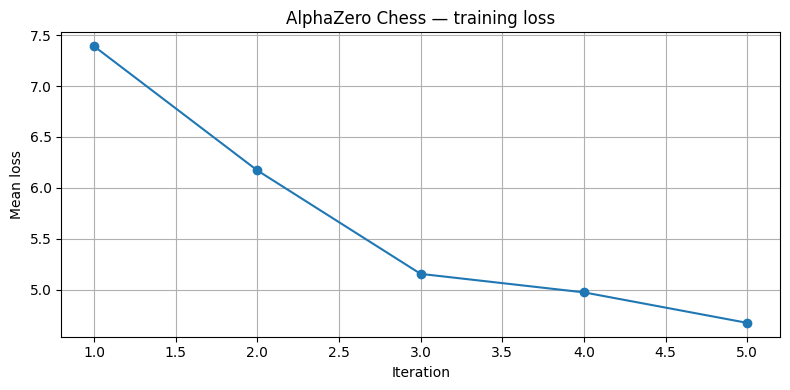

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Mean loss")
plt.title("AlphaZero Chess — training loss")
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Save checkpoint

In [7]:
torch.save(model.state_dict(), "model_chess.pt")
print("Saved model_chess.pt")

Saved model_chess.pt


## 7. Play against the trained model

You play as **White**. Enter moves in UCI format (e.g. `e2e4`, `g1f3`, `e1g1` for kingside castle).

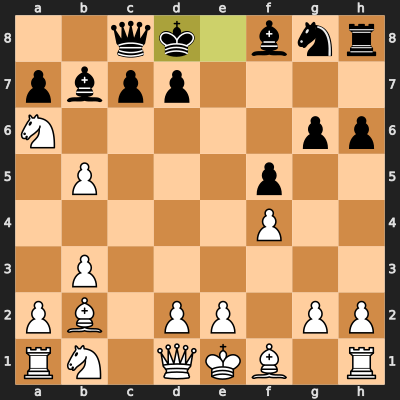

Illegal move. Legal moves: a6b8, a6c7, a6c5, a6b4, b2h8, b2g7, b2f6, b2e5, b2d4, b2c3...
Illegal move. Legal moves: a6b8, a6c7, a6c5, a6b4, b2h8, b2g7, b2f6, b2e5, b2d4, b2c3...


In [ ]:
def show_board(board, last_move=None):
    clear_output(wait=True)
    svg = chess.svg.board(board, lastmove=last_move, size=400)
    display(SVG(svg))


model.eval()
board = chess.Board()
human_colour = chess.WHITE
last_move = None

show_board(board)

while not board.is_game_over():
    if board.turn == human_colour:
        # Human move
        legal_ucis = [m.uci() for m in board.legal_moves]
        while True:
            uci = input("Your move (UCI, e.g. e2e4): ").strip()
            if uci in legal_ucis:
                break
            print(f"Illegal move. Legal moves: {', '.join(legal_ucis[:10])}{'...' if len(legal_ucis) > 10 else ''}")
        last_move = chess.Move.from_uci(uci)
        board.push(last_move)
    else:
        # AI move
        ai_player = -1  # Black
        policy = mcts.search(board.copy(), ai_player)
        action = int(np.argmax(policy))
        uci = game.action_to_uci(action)
        last_move = chess.Move.from_uci(uci)
        board.push(last_move)
        print(f"AI plays: {uci}")

    show_board(board, last_move)

# Game over
result = board.result()
outcome = board.outcome()
if outcome is None:
    print("Game over — draw by agreement or repetition.")
elif outcome.winner == human_colour:
    print(f"You win! ({result})")
elif outcome.winner is None:
    print(f"Draw! ({result})")
else:
    print(f"AI wins! ({result})")